# EDA — Log-retornos diarios (23 activos del S&P 500)

Análisis exploratorio **descriptivo** de los datos sobre los que se entrenarán los 64 modelos del Taller B3-T4.

Alcance:
- Sólo log-retornos (lo que efectivamente ven los modelos).
- Estadísticas y plots; **sin** conclusiones de modelado.
- Datos descargados de yfinance en cada ejecución (sin caché en disco).

## 1. Setup

In [1]:
import os, sys

def detect_env():
    try:
        import google.colab  # noqa: F401
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'ENV={ENV}  BASE={BASE}')

ENV=local  BASE=/mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX


In [2]:
# Dependencias opcionales (instalar sólo si faltan, p.ej. en Colab limpio).
for pkg in ('seaborn', 'statsmodels'):
    try:
        __import__(pkg)
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')  # silenciar warnings de KPSS p-value clipping

from dataset_utils import load_data, TICKERS

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Carga de datos

In [4]:
data, df = load_data(verbose=True)   # log-retornos por defecto

print(f'Shape:        {data.shape}')
print(f'dtype:        {data.dtype}')
print(f'Rango fechas: {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Tickers ({len(df.columns)}): {list(df.columns)}')

> Descargando datos desde 1945-01-01 hasta hoy...


[*********************100%***********************]  23 of 23 completed


> Log-retornos calculados — shape (16195, 23)
Shape:        (16195, 23)
dtype:        float32
Rango fechas: 1962-01-03  →  2026-05-08
Tickers (23): ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


In [5]:
df.head()

Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019802,0.009693,-0.009820,-0.002259,0.013334,-0.008265,0.000000,0.032925,-0.010085,...,-0.013746,-0.015670,-0.022533,0.020791,0.007491,-0.018518,-0.042802,-0.002912,-0.010990,0.014743
1962-01-04,-0.014706,-0.009852,0.025399,0.000000,-0.009090,0.000000,-0.008333,-0.003091,0.004041,-0.011894,...,-0.003466,-0.010578,0.007571,-0.004123,0.000000,0.006985,-0.010257,-0.008784,-0.016714,0.002435
1962-01-05,-0.022473,-0.020000,0.009361,-0.024418,-0.025436,0.003308,-0.021142,-0.021910,0.004024,-0.025975,...,0.010363,-0.016090,-0.022876,-0.025106,-0.026468,0.011533,-0.034461,-0.005900,-0.007048,-0.022140
1962-01-08,-0.007604,0.002522,0.006192,-0.011299,-0.004693,-0.003308,0.002135,0.004735,0.015936,-0.001756,...,-0.020834,-0.016348,-0.010335,-0.004246,-0.005763,-0.006904,0.003043,-0.017912,-0.027241,-0.002491
1962-01-09,-0.007664,0.002516,0.009216,0.000000,0.014019,0.019676,0.002129,-0.001576,0.003945,0.005258,...,-0.014135,0.010931,0.018018,-0.021506,0.000000,-0.018647,0.004549,-0.024391,-0.001454,-0.002496


In [6]:
df.tail()

Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-04,-0.016571,-0.027103,-0.016878,-0.000692,0.008618,-0.017320,-0.013942,-0.007814,0.009325,-0.021128,...,-0.017790,-0.013248,-0.004975,-0.003251,-0.006618,-0.015410,0.008434,0.003870,-0.026422,0.006135
2026-05-05,0.017520,0.013822,0.033509,0.004836,0.001871,-0.008226,-0.022259,-0.004388,0.000229,0.021722,...,0.020933,0.006003,0.003702,-0.009370,0.008862,-0.008482,0.000354,0.000937,0.010266,0.007713
2026-05-06,-0.033237,0.024434,0.024396,-0.027954,-0.039603,0.072728,-0.007414,-0.021110,-0.005428,0.064663,...,0.050791,-0.004132,0.009511,-0.013692,0.025713,-0.036658,0.003617,-0.009958,0.020493,-0.040787
2026-05-07,-0.006053,0.004773,-0.034284,-0.002128,-0.014470,0.005537,-0.003094,-0.004502,0.001410,-0.010518,...,-0.013213,-0.009438,-0.010149,0.006041,-0.019223,-0.016235,-0.011157,-0.001061,-0.012519,-0.014292
2026-05-08,-0.004981,0.027030,0.001963,-0.012387,-0.004834,-0.005907,-0.009908,-0.000752,-0.003543,-0.018274,...,-0.001513,-0.005362,-0.000128,-0.011662,-0.003205,-0.013415,-0.008226,-0.120583,0.002462,-0.013807


## 3. Cobertura temporal y completitud

Después de `load_data()` los log-retornos llegan ya sin NaN (el `dropna` interno alinea todas las series).

In [7]:
print('NaN por ticker:')
print(df.isna().sum().to_string())

NaN por ticker:
Ticker
AEP    0
BA     0
CAT    0
CNP    0
CVX    0
DIS    0
DTE    0
ED     0
GD     0
GE     0
HON    0
HPQ    0
IBM    0
IP     0
JNJ    0
KO     0
KR     0
MMM    0
MO     0
MRK    0
MSI    0
PG     0
XOM    0


In [8]:
primer_dato = df.apply(lambda s: s.first_valid_index()).sort_values()
primer_dato.name = 'primer_dato'
primer_dato.to_frame()

,primer_dato
Ticker,
AEP,1962-01-03
MSI,1962-01-03
MRK,1962-01-03
MO,1962-01-03
MMM,1962-01-03
KR,1962-01-03
KO,1962-01-03
JNJ,1962-01-03
IP,1962-01-03


In [9]:
filas_por_decada = df.groupby(df.index.year // 10 * 10).size()
filas_por_decada.name = 'n_dias'
filas_por_decada.index.name = 'decada'
filas_por_decada.to_frame()

,n_dias
decada,
1960,1986
1970,2526
1980,2528
1990,2528
2000,2515
2010,2516
2020,1596


## 4. Estadísticas descriptivas por ticker

Tabla ordenada por volatilidad (std descendente). Se añaden `skew` y `kurt` (kurtosis exceso de Fisher, normal=0).

In [10]:
stats_tbl = df.describe().T
stats_tbl['skew'] = df.skew()
stats_tbl['kurt'] = df.kurt()
stats_tbl = stats_tbl.sort_values('std', ascending=False)
stats_tbl.round(5)

,count,mean,std,min,25%,50%,75%,max,skew,kurt
Ticker,,,,,,,,,,
MSI,16195.0,0.00040,0.02294,-0.26236,-0.01079,0.00000,0.01151,0.22674,-0.33999,9.07718
HPQ,16195.0,0.00039,0.02260,-0.22681,-0.01097,0.00000,0.01198,0.15946,-0.30447,7.10598
BA,16195.0,0.00044,0.02139,-0.27244,-0.01046,0.00000,0.01097,0.21768,-0.03921,9.20375
DIS,16195.0,0.00047,0.01982,-0.34382,-0.00957,0.00000,0.01026,0.17476,-0.37840,12.28973
IP,16195.0,0.00023,0.01937,-0.31408,-0.00972,0.00000,0.01010,0.19790,-0.23606,11.74551
GD,16195.0,0.00047,0.01886,-0.15628,-0.00891,0.00000,0.00924,0.18232,0.15853,5.48705
CAT,16195.0,0.00047,0.01867,-0.24362,-0.00918,0.00000,0.01017,0.13735,-0.23865,6.37706
HON,16195.0,0.00033,0.01819,-0.34804,-0.00856,0.00000,0.00905,0.27172,-0.26992,19.91893
KR,16195.0,0.00047,0.01812,-0.29480,-0.00866,0.00000,0.00952,0.26042,-0.39325,14.59740


## 5. Distribución de log-retornos

Histograma global (eje y log) + grid por ticker + QQ-plots representativos.

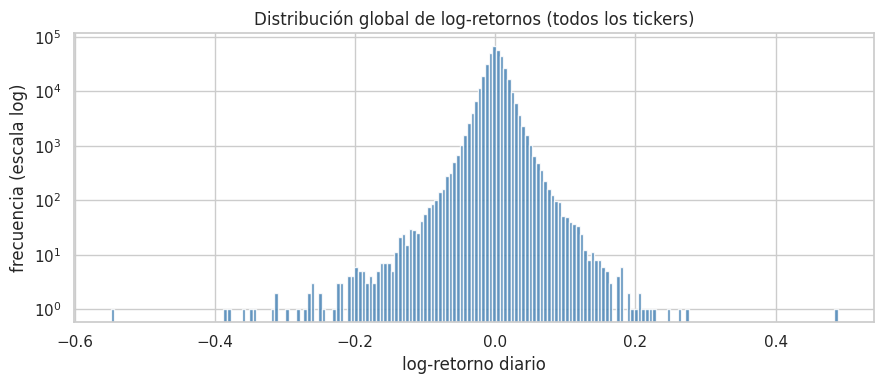

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df.values.ravel(), bins=200, color='steelblue', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('log-retorno diario')
ax.set_ylabel('frecuencia (escala log)')
ax.set_title('Distribución global de log-retornos (todos los tickers)')
plt.tight_layout(); plt.show()

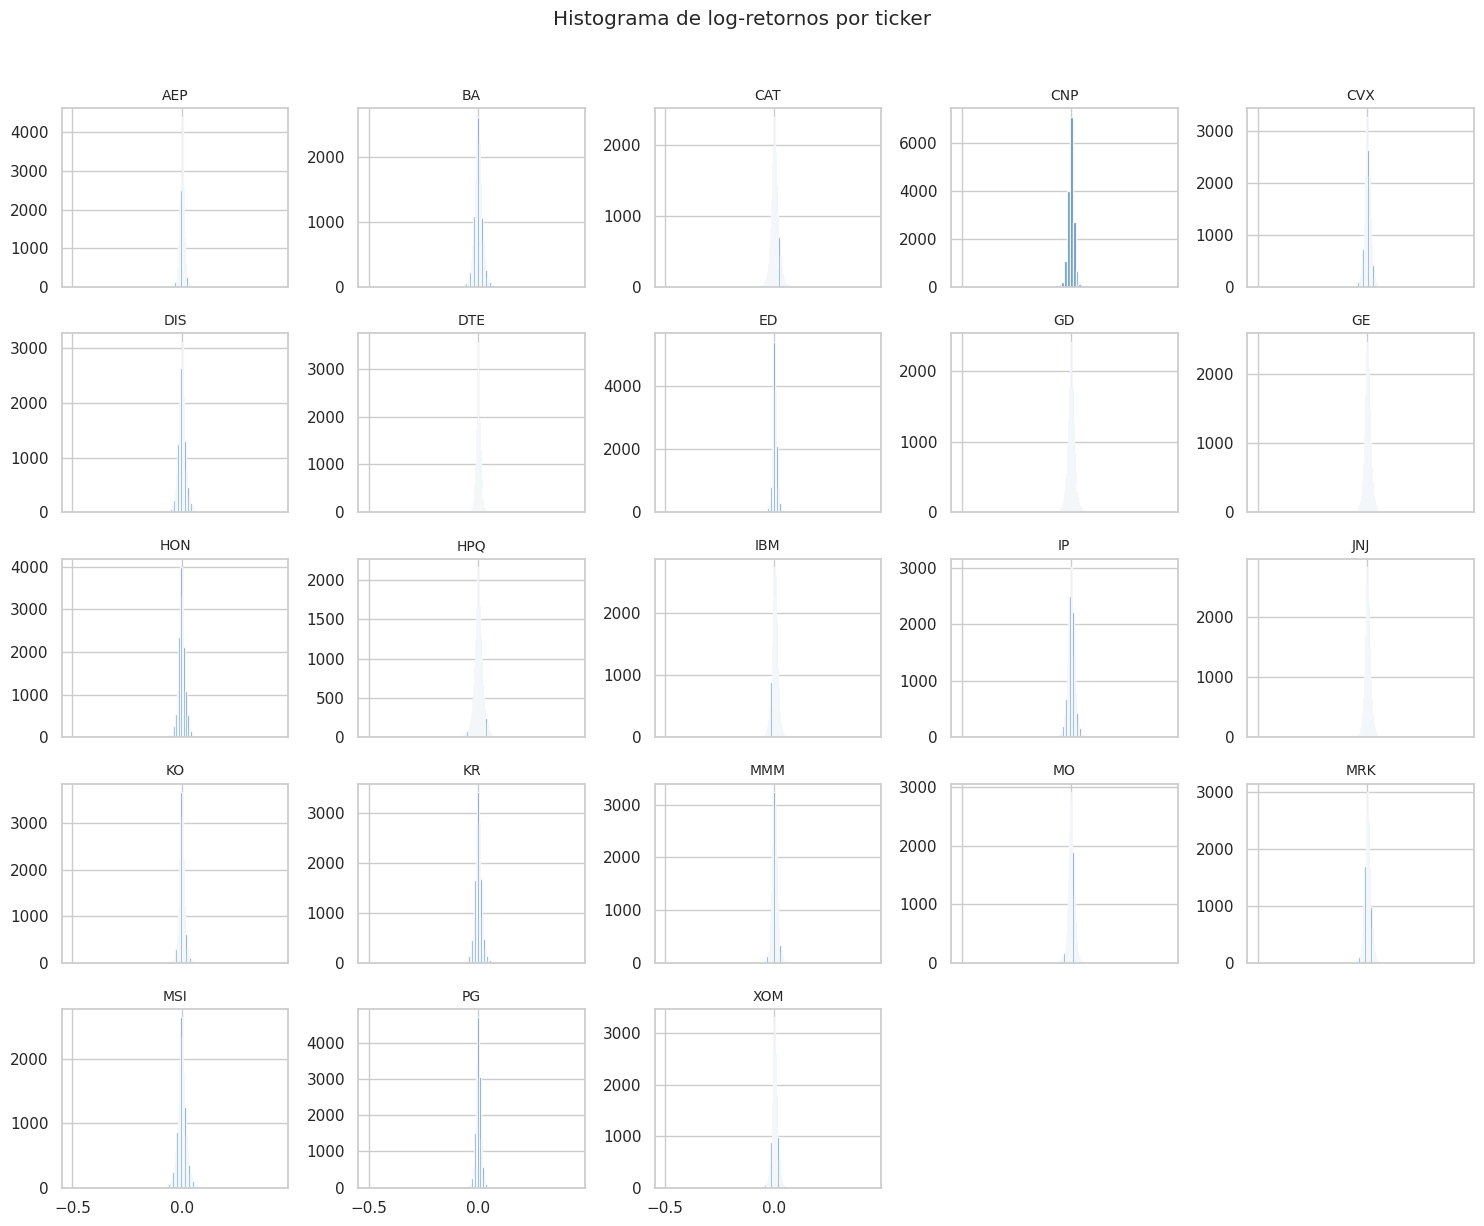

In [12]:
n = len(df.columns)
ncols = 5
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2.4 * nrows), sharex=True)
axes = axes.ravel()
x_lim = (df.values.min(), df.values.max())
for i, t in enumerate(df.columns):
    axes[i].hist(df[t].values, bins=80, color='steelblue', alpha=0.85)
    axes[i].set_title(t, fontsize=10)
    axes[i].set_xlim(x_lim)
for j in range(n, len(axes)):
    axes[j].axis('off')
fig.suptitle('Histograma de log-retornos por ticker', y=1.02)
plt.tight_layout(); plt.show()

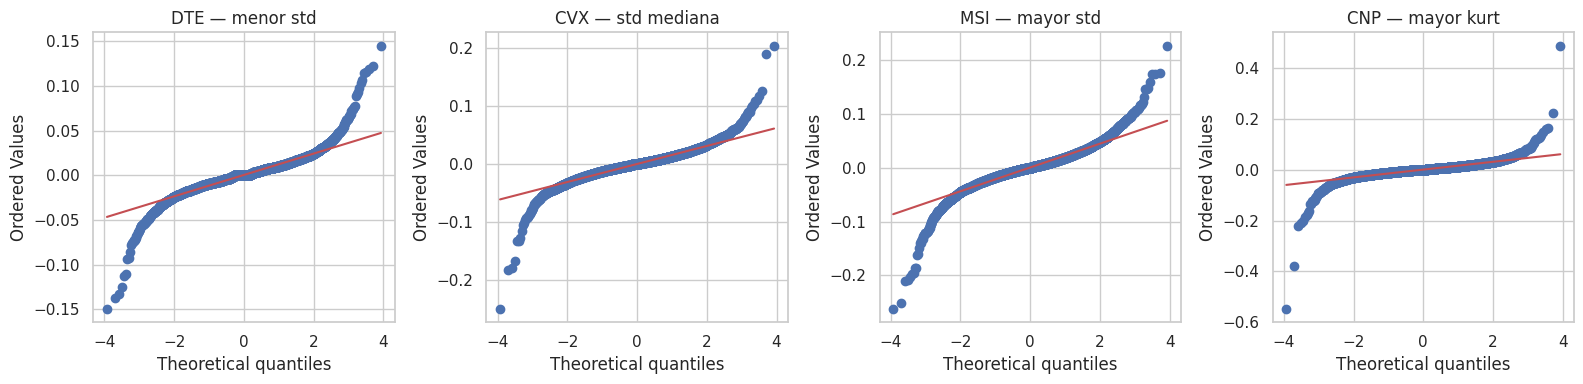

In [13]:
# 4 tickers representativos: menor std, mediana de std, mayor std, mayor kurtosis.
stds = df.std().sort_values()
kurts = df.kurt().sort_values()
tickers_qq = [stds.index[0], stds.index[len(stds)//2], stds.index[-1], kurts.index[-1]]
tickers_qq = list(dict.fromkeys(tickers_qq))   # quitar duplicados conservando orden
etiquetas = ['menor std', 'std mediana', 'mayor std', 'mayor kurt']

fig, axes = plt.subplots(1, len(tickers_qq), figsize=(4 * len(tickers_qq), 4))
for ax, t, lbl in zip(axes, tickers_qq, etiquetas):
    stats.probplot(df[t].values, dist='norm', plot=ax)
    ax.set_title(f'{t} — {lbl}')
plt.tight_layout(); plt.show()

## 6. Series temporales de log-retornos

Multipanel con todas las series. Marcadores grises sobre eventos históricos conocidos (sólo contexto).

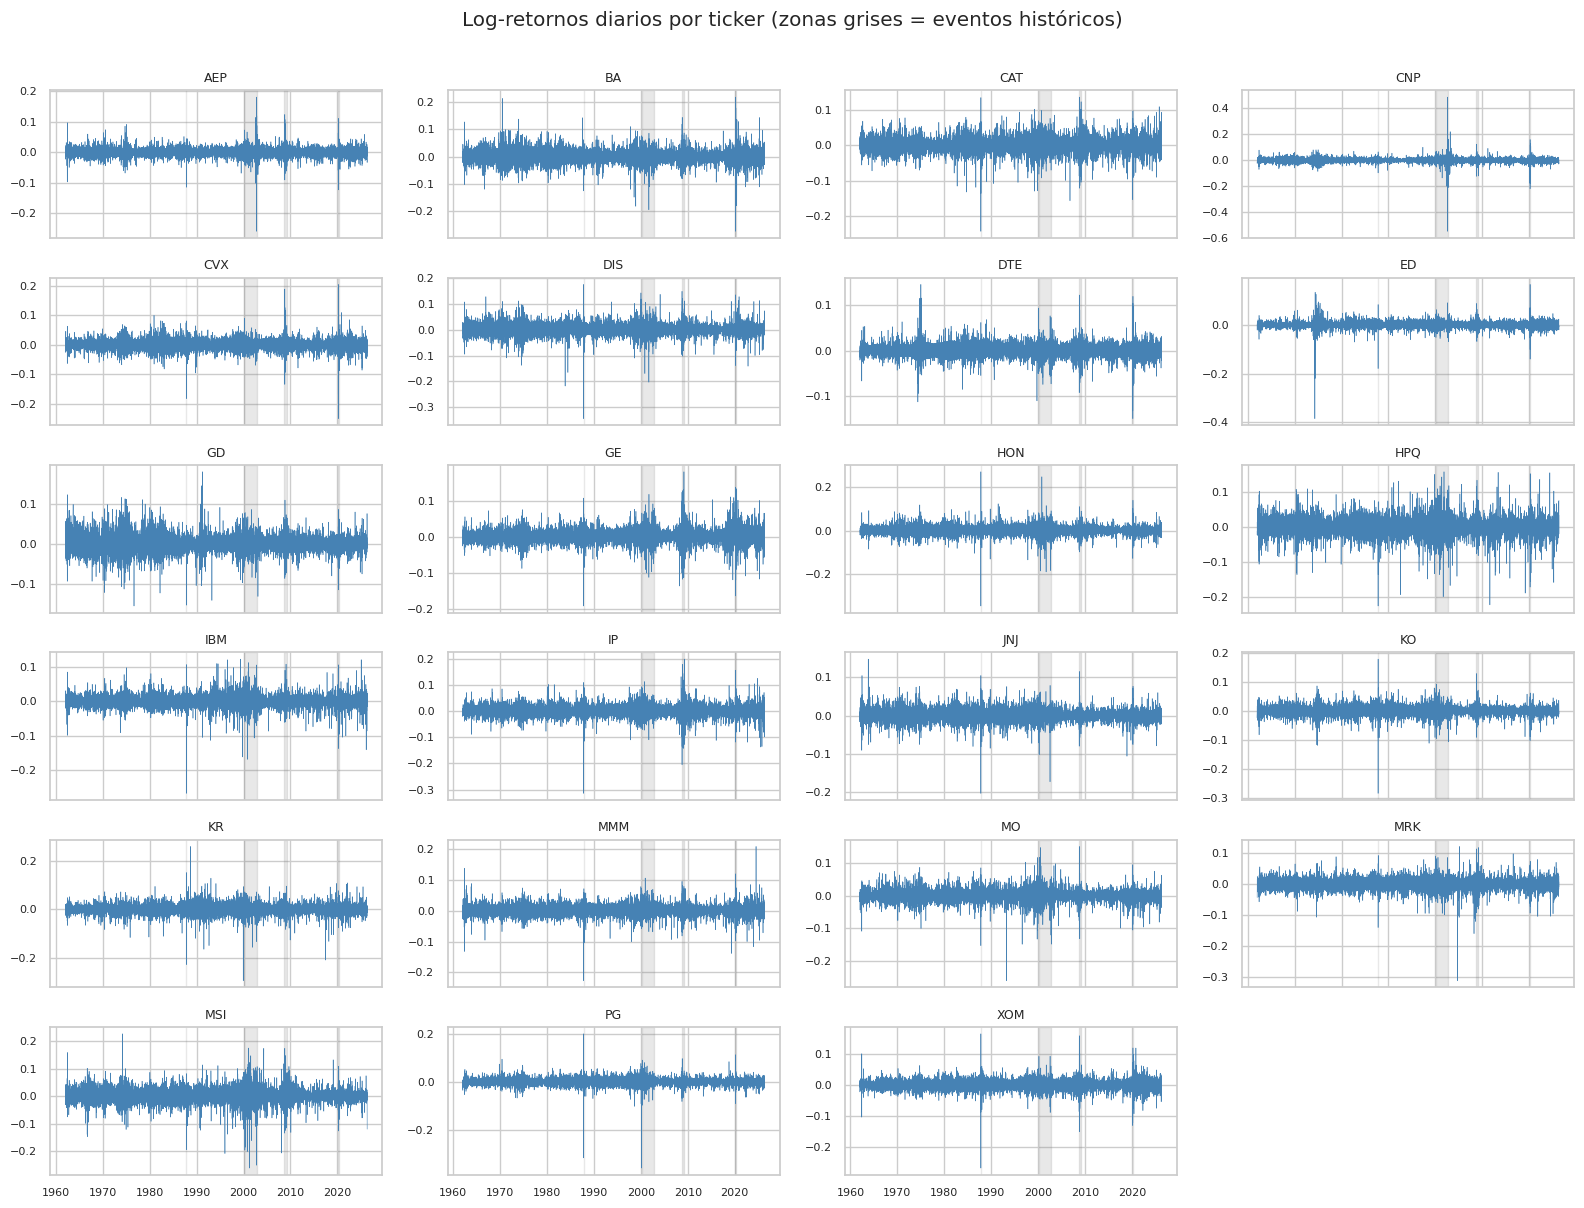

In [14]:
eventos = [
    ('1987-10-19', '1987-10-26', 'Black Monday'),
    ('2000-03-10', '2002-10-09', 'Dot-com'),
    ('2008-09-15', '2009-03-09', 'GFC'),
    ('2020-02-20', '2020-04-07', 'COVID'),
]

n = len(df.columns)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 2 * nrows), sharex=True)
axes = axes.ravel()
for i, t in enumerate(df.columns):
    ax = axes[i]
    ax.plot(df.index, df[t].values, lw=0.4, color='steelblue')
    for ini, fin, _ in eventos:
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color='grey', alpha=0.18)
    ax.set_title(t, fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
for j in range(n, len(axes)):
    axes[j].axis('off')
fig.suptitle('Log-retornos diarios por ticker (zonas grises = eventos históricos)', y=1.005)
plt.tight_layout(); plt.show()

## 7. Volatilidad rodante

Std móvil a 60 días por ticker, y heatmap años × tickers de la volatilidad anual.

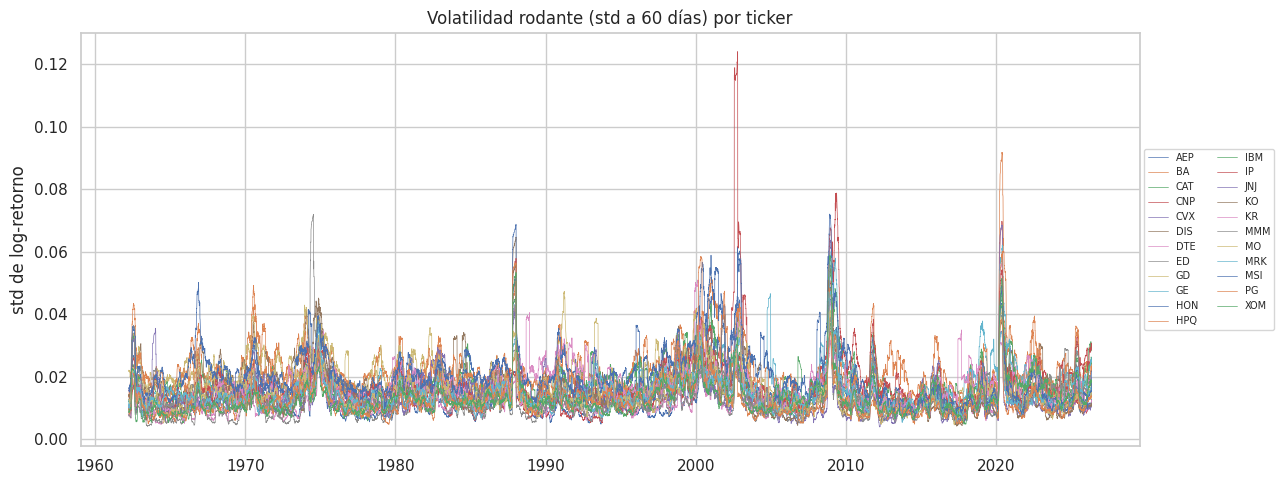

In [15]:
vol = df.rolling(60).std()
fig, ax = plt.subplots(figsize=(13, 5))
for t in df.columns:
    ax.plot(vol.index, vol[t], lw=0.5, label=t)
ax.set_title('Volatilidad rodante (std a 60 días) por ticker')
ax.set_ylabel('std de log-retorno')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2, fontsize=7)
plt.tight_layout(); plt.show()

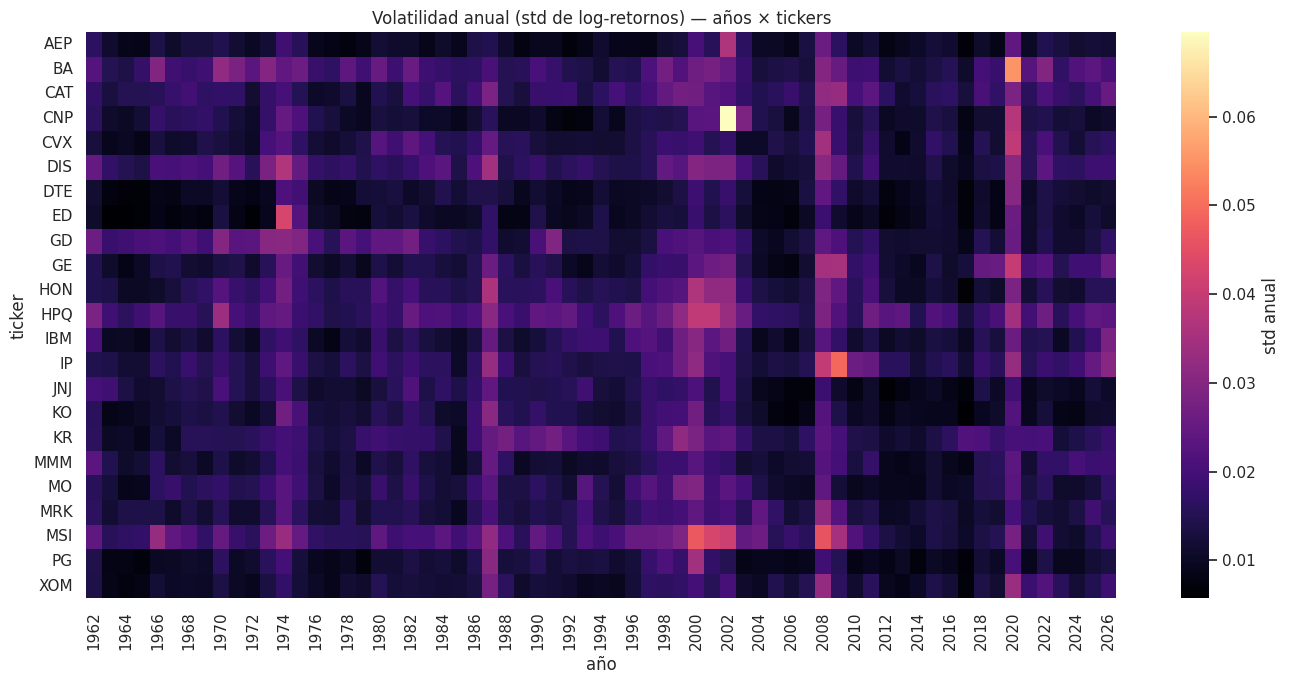

In [16]:
vol_anual = df.groupby(df.index.year).std()
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(vol_anual.T, cmap='magma', cbar_kws={'label': 'std anual'}, ax=ax)
ax.set_xlabel('año'); ax.set_ylabel('ticker')
ax.set_title('Volatilidad anual (std de log-retornos) — años × tickers')
plt.tight_layout(); plt.show()

## 8. Correlaciones entre tickers

Matriz de correlación de Pearson sobre toda la muestra y correlación rodante promedio (60 días).

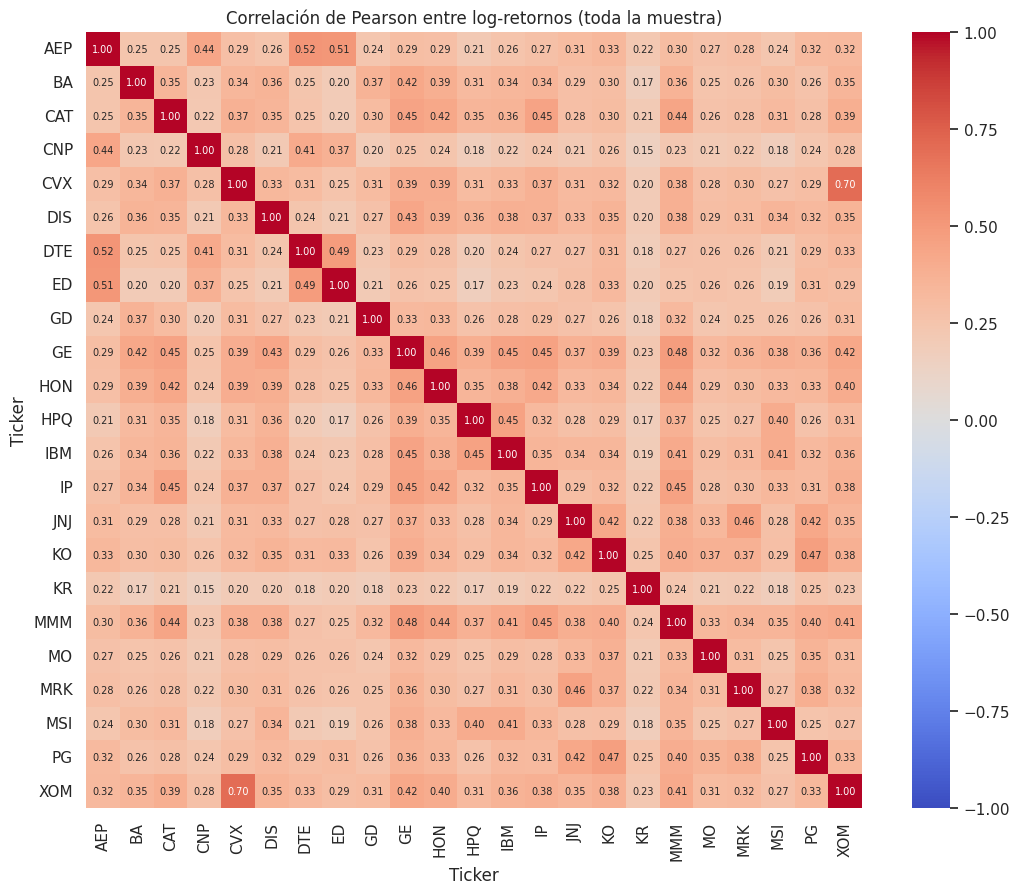

In [17]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlación de Pearson entre log-retornos (toda la muestra)')
plt.tight_layout(); plt.show()

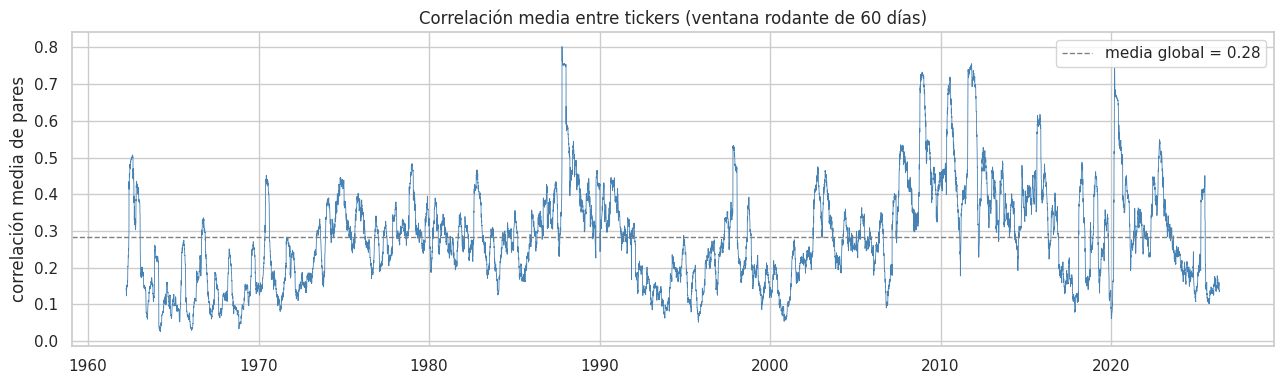

In [18]:
# Correlación rodante promedio entre todos los pares (off-diagonal) por ventana de 60 días.
ventana = 60
n_act = df.shape[1]
corr_media = []
for i in range(ventana, len(df)):
    sub = df.iloc[i - ventana:i]
    c = sub.corr().values
    iu = np.triu_indices(n_act, k=1)
    corr_media.append(c[iu].mean())
corr_media = pd.Series(corr_media, index=df.index[ventana:])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(corr_media.index, corr_media.values, color='steelblue', lw=0.6)
ax.set_title(f'Correlación media entre tickers (ventana rodante de {ventana} días)')
ax.set_ylabel('correlación media de pares')
ax.axhline(corr_media.mean(), color='grey', ls='--', lw=1, label=f'media global = {corr_media.mean():.2f}')
ax.legend()
plt.tight_layout(); plt.show()

## 9. Autocorrelación

ACF de los log-retornos y de su valor absoluto, en 4 tickers representativos.

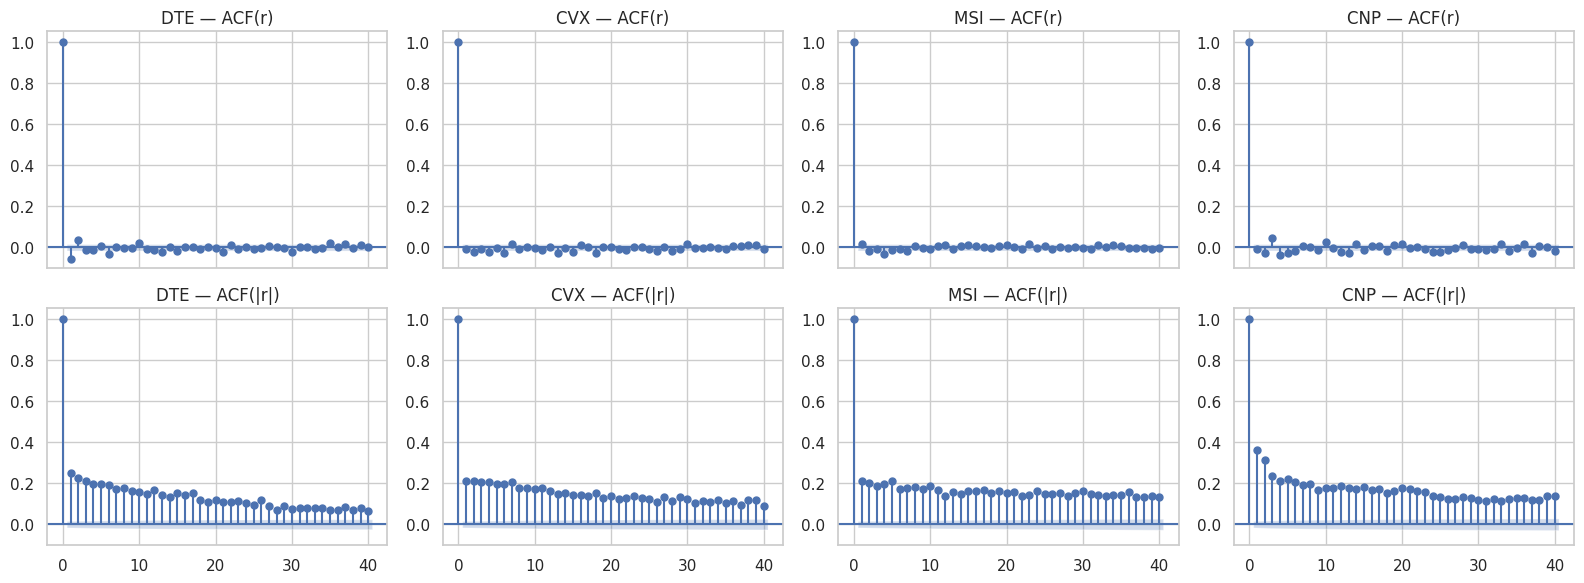

In [19]:
tickers_acf = tickers_qq   # reusar los 4 representativos de la sección 5
lags = 40

fig, axes = plt.subplots(2, len(tickers_acf), figsize=(4 * len(tickers_acf), 6), sharex=True)
for j, t in enumerate(tickers_acf):
    plot_acf(df[t].values, lags=lags, ax=axes[0, j], title=f'{t} — ACF(r)')
    plot_acf(np.abs(df[t].values), lags=lags, ax=axes[1, j], title=f'{t} — ACF(|r|)')
for ax in axes.ravel():
    ax.set_ylim(-0.1, 1.05)
plt.tight_layout(); plt.show()

## 10. Estacionariedad — ADF y KPSS

Tests sobre **log-retornos** y comparativa con **precios crudos** para ilustrar el contraste.

- **ADF**: H₀ = la serie tiene raíz unitaria (no estacionaria). Se rechaza si `p < α`.
- **KPSS**: H₀ = la serie es estacionaria en torno a una constante. Se rechaza si `p < α` (es decir, evidencia de no estacionariedad).

Si ambos coinciden (`ADF rechaza` + `KPSS no rechaza`), la evidencia de estacionariedad es robusta.

In [20]:
def adf_row(serie):
    s = pd.Series(serie).dropna().values
    stat, pval, nlags, nobs, crit, _ = adfuller(s, autolag='AIC')
    return {
        'adf_stat': stat, 'p_value': pval, 'n_lags': nlags, 'n_obs': nobs,
        'crit_1%': crit['1%'], 'crit_5%': crit['5%'], 'crit_10%': crit['10%'],
        'estacionaria_5%': pval < 0.05,
    }

adf_log = pd.DataFrame({t: adf_row(df[t]) for t in df.columns}).T
adf_log.index.name = 'ticker'
adf_log.round(5)

,adf_stat,p_value,n_lags,n_obs,crit_1%,crit_5%,crit_10%,estacionaria_5%
ticker,,,,,,,,
AEP,-22.918882,0.0,37,16157,-3.430755,-2.861719,-2.566865,True
BA,-22.795076,0.0,30,16164,-3.430755,-2.861719,-2.566865,True
CAT,-27.1631,0.0,24,16170,-3.430754,-2.861719,-2.566865,True
CNP,-21.76352,0.0,42,16152,-3.430755,-2.861719,-2.566865,True
CVX,-32.677543,0.0,17,16177,-3.430754,-2.861719,-2.566865,True
DIS,-75.531152,0.0,2,16192,-3.430754,-2.861719,-2.566865,True
DTE,-34.749274,0.0,14,16180,-3.430754,-2.861719,-2.566865,True
ED,-29.987862,0.0,16,16178,-3.430754,-2.861719,-2.566865,True
GD,-53.658862,0.0,5,16189,-3.430754,-2.861719,-2.566865,True


In [21]:
n_total = len(adf_log)
for alpha in (0.01, 0.05, 0.10):
    n_rech = (adf_log['p_value'] < alpha).sum()
    print(f'ADF α={alpha:.2f}: {n_rech}/{n_total} tickers rechazan H0 (= estacionarios)')

ADF α=0.01: 23/23 tickers rechazan H0 (= estacionarios)
ADF α=0.05: 23/23 tickers rechazan H0 (= estacionarios)
ADF α=0.10: 23/23 tickers rechazan H0 (= estacionarios)


In [22]:
# Comparativa: ADF sobre precios de cierre (no estacionarios) vs log-retornos.
_, df_precio = load_data(use_log_returns=False, verbose=False)
df_precio = df_precio[df.columns]

adf_precio = pd.DataFrame({t: adf_row(df_precio[t]) for t in df_precio.columns}).T
adf_precio.index.name = 'ticker'

comparativa = pd.DataFrame({
    'p_value_precio':       adf_precio['p_value'],
    'p_value_log_retorno':  adf_log['p_value'],
    'estacionaria_5%_precio':       adf_precio['p_value'] < 0.05,
    'estacionaria_5%_log_retorno':  adf_log['p_value']    < 0.05,
})
comparativa.round(5)

,p_value_precio,p_value_log_retorno,estacionaria_5%_precio,estacionaria_5%_log_retorno
ticker,,,,
AEP,1.0,0.0,False,True
BA,0.666948,0.0,False,True
CAT,1.0,0.0,False,True
CNP,1.0,0.0,False,True
CVX,0.998877,0.0,False,True
DIS,0.828882,0.0,False,True
DTE,1.0,0.0,False,True
ED,0.999076,0.0,False,True
GD,1.0,0.0,False,True


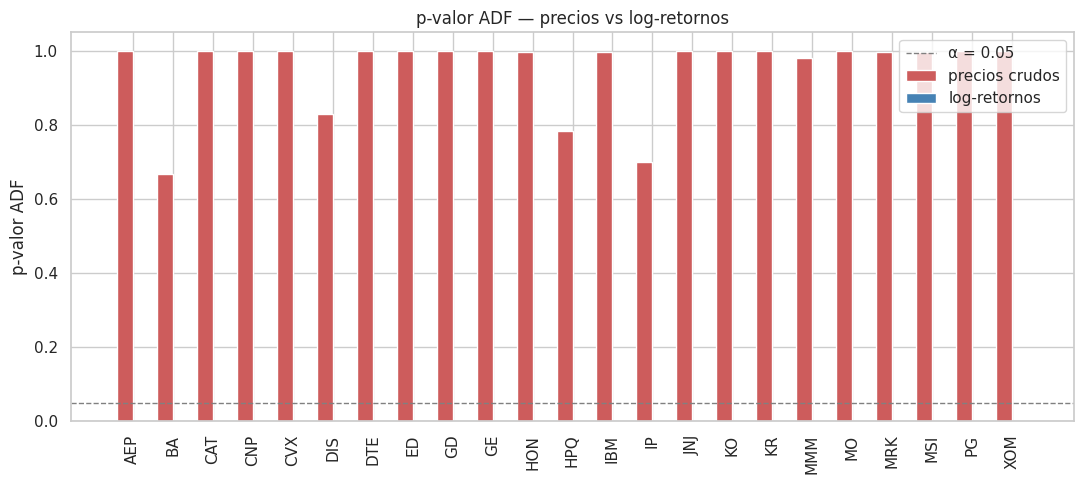

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparativa))
ax.bar(x - 0.2, comparativa['p_value_precio'],      width=0.4, label='precios crudos', color='indianred')
ax.bar(x + 0.2, comparativa['p_value_log_retorno'], width=0.4, label='log-retornos',  color='steelblue')
ax.axhline(0.05, color='grey', ls='--', lw=1, label='α = 0.05')
ax.set_xticks(x); ax.set_xticklabels(comparativa.index, rotation=90)
ax.set_ylabel('p-valor ADF')
ax.set_title('p-valor ADF — precios vs log-retornos')
ax.legend()
plt.tight_layout(); plt.show()

In [24]:
def kpss_row(serie):
    s = pd.Series(serie).dropna().values
    stat, pval, nlags, crit = kpss(s, regression='c', nlags='auto')
    return {
        'kpss_stat': stat, 'p_value': pval, 'n_lags': nlags,
        'crit_1%': crit['1%'], 'crit_5%': crit['5%'], 'crit_10%': crit['10%'],
        'estacionaria_5%': pval >= 0.05,   # H0 = estacionariedad → NO rechazar = estacionaria
    }

kpss_log = pd.DataFrame({t: kpss_row(df[t]) for t in df.columns}).T
kpss_log.index.name = 'ticker'
kpss_log.round(5)

,kpss_stat,p_value,n_lags,crit_1%,crit_5%,crit_10%,estacionaria_5%
ticker,,,,,,,
AEP,0.154311,0.1,17,0.739,0.463,0.347,True
BA,0.064218,0.1,12,0.739,0.463,0.347,True
CAT,0.186051,0.1,23,0.739,0.463,0.347,True
CNP,0.059187,0.1,19,0.739,0.463,0.347,True
CVX,0.028723,0.1,22,0.739,0.463,0.347,True
DIS,0.142981,0.1,1,0.739,0.463,0.347,True
DTE,0.171605,0.1,19,0.739,0.463,0.347,True
ED,0.128904,0.1,12,0.739,0.463,0.347,True
GD,0.061348,0.1,21,0.739,0.463,0.347,True


In [25]:
n_total = len(kpss_log)
for alpha in (0.01, 0.05, 0.10):
    n_no_rech = (kpss_log['p_value'] >= alpha).sum()
    print(f'KPSS α={alpha:.2f}: {n_no_rech}/{n_total} tickers NO rechazan H0 (= estacionarios)')

KPSS α=0.01: 23/23 tickers NO rechazan H0 (= estacionarios)
KPSS α=0.05: 23/23 tickers NO rechazan H0 (= estacionarios)
KPSS α=0.10: 23/23 tickers NO rechazan H0 (= estacionarios)


## 11. Outliers / valores extremos

Días con mayor magnitud agregada de log-retorno y dispersión por ticker.

In [26]:
abs_sum = df.abs().sum(axis=1).sort_values(ascending=False)
top_dias = abs_sum.head(10)

filas = []
for fecha in top_dias.index:
    fila = df.loc[fecha]
    top3 = fila.abs().sort_values(ascending=False).head(3).index.tolist()
    filas.append({
        'fecha': fecha.date(),
        'suma_abs_logret': abs_sum.loc[fecha],
        'top_3_tickers': ', '.join(f'{t}({fila[t]:+.3f})' for t in top3),
    })
pd.DataFrame(filas)

,fecha,suma_abs_logret,top_3_tickers
0,1987-10-19,4.859758,"HON(-0.348), DIS(-0.344), PG(-0.318)"
1,2008-10-13,2.525620,"CVX(+0.189), MSI(+0.174), XOM(+0.159)"
2,2020-03-12,2.465984,"BA(-0.200), CNP(-0.172), DIS(-0.139)"
3,2020-03-16,2.428808,"BA(-0.272), CNP(-0.220), CVX(-0.180)"
4,2008-10-28,2.265787,"MSI(+0.145), BA(+0.144), CVX(+0.126)"
5,2020-03-24,2.188248,"CVX(+0.205), BA(+0.190), HON(+0.140)"
6,2020-03-09,2.011279,"CNP(-0.178), CVX(-0.167), CAT(-0.154)"
7,2008-10-15,1.947346,"IP(-0.205), XOM(-0.150), CVX(-0.133)"
8,1987-10-26,1.891944,"MSI(-0.186), HON(-0.158), HPQ(-0.137)"
9,2008-10-09,1.807172,"MSI(-0.135), CVX(-0.133), XOM(-0.124)"


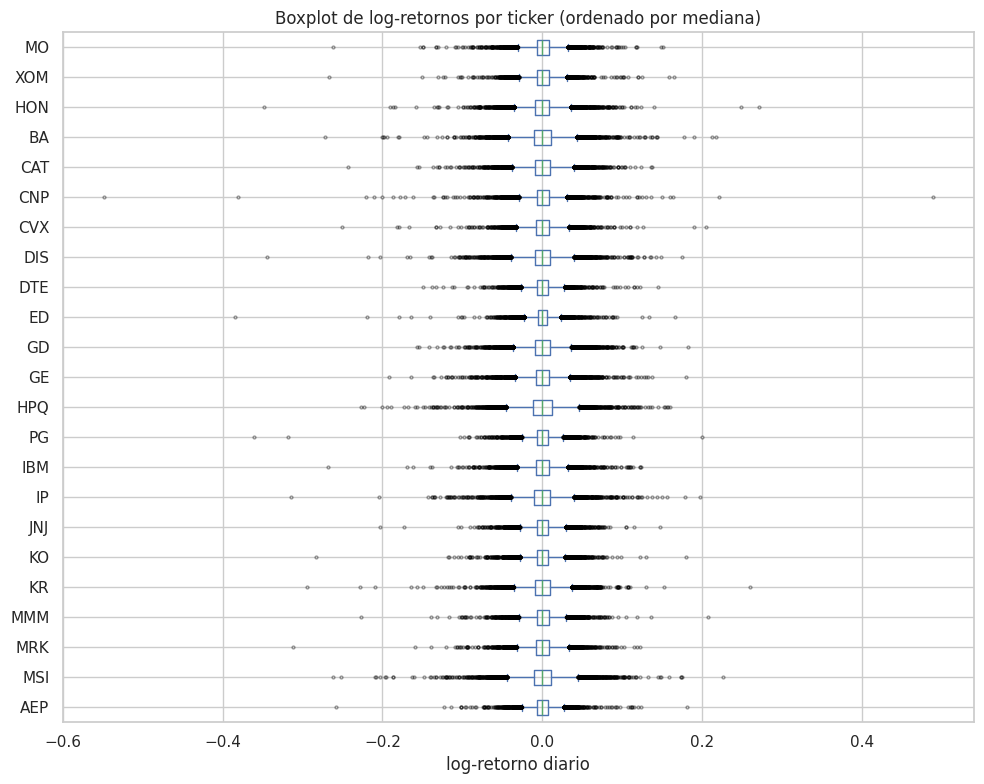

In [27]:
orden = df.median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 8))
df[orden].plot.box(vert=False, ax=ax, flierprops={'markersize': 2, 'alpha': 0.4})
ax.set_title('Boxplot de log-retornos por ticker (ordenado por mediana)')
ax.set_xlabel('log-retorno diario')
plt.tight_layout(); plt.show()

## 12. Resumen descriptivo

Ficha técnica calculada del dataset (no recomendaciones de modelado).

In [28]:
ticker_max_std  = df.std().idxmax()
ticker_min_std  = df.std().idxmin()
ticker_max_kurt = df.kurt().idxmax()
ticker_max_skew = df.skew().abs().idxmax()
iu = np.triu_indices(df.shape[1], k=1)
corr_media_global = df.corr().values[iu].mean()
n_estac_adf   = int((adf_log['p_value']  < 0.05).sum())
n_estac_kpss  = int((kpss_log['p_value'] >= 0.05).sum())

print('FICHA TÉCNICA — log-retornos diarios')
print('=' * 50)
print(f'Rango temporal:           {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Nº de días (filas):       {len(df):,}')
print(f'Nº de tickers:            {df.shape[1]}')
print(f'NaN totales:              {int(df.isna().sum().sum())}')
print('-' * 50)
print(f'Ticker más volátil:       {ticker_max_std}  (std={df.std().max():.5f})')
print(f'Ticker menos volátil:     {ticker_min_std}  (std={df.std().min():.5f})')
print(f'Mayor kurtosis:           {ticker_max_kurt}  (kurt={df.kurt().max():.2f})')
print(f'Mayor |skew|:             {ticker_max_skew}  (skew={df.skew().loc[ticker_max_skew]:+.3f})')
print('-' * 50)
print(f'Correlación media global: {corr_media_global:.3f}')
print(f'ADF  α=5%: estacionarios  {n_estac_adf}/{df.shape[1]}')
print(f'KPSS α=5%: estacionarios  {n_estac_kpss}/{df.shape[1]}')

FICHA TÉCNICA — log-retornos diarios
Rango temporal:           1962-01-03  →  2026-05-08
Nº de días (filas):       16,195
Nº de tickers:            23
NaN totales:              0
--------------------------------------------------
Ticker más volátil:       MSI  (std=0.02294)
Ticker menos volátil:     DTE  (std=0.01249)
Mayor kurtosis:           CNP  (kurt=130.67)
Mayor |skew|:             ED  (skew=-2.200)
--------------------------------------------------
Correlación media global: 0.309
ADF  α=5%: estacionarios  23/23
KPSS α=5%: estacionarios  23/23
